## ESPEN Soccer Data

| Fixtures.csv = all matches played in 2024/2025 | The data was compiled from a "soccer data API" | There are 17 columns and 4864 columns | I looked at the win_rate for the home and away teams specifically


## RESEARCH QUESTION

Do home teams win more often than away teams?

In [54]:
import pandas as pd

In [55]:
teamFixtures = pd.read_csv("fixtures.csv")
print(teamFixtures.shape)
teamFixtures.head()

(4864, 17)


,Rn,seasonType,leagueId,eventId,date,venueId,attendance,homeTeamId,awayTeamId,homeTeamWinner,awayTeamWinner,homeTeamScore,awayTeamScore,homeTeamShootoutScore,awayTeamShootoutScore,statusId,updateTime
0,1,12136,3922,689519,2024-01-01 05:00:00,8680,61916,627,4396,True,False,5,0,0,0,28,2024-01-07 03:20:23
1,2,12136,3922,694555,2024-01-01 13:30:00,4775,0,658,1928,False,True,1,2,0,0,28,2024-01-07 03:20:24
2,3,12136,3922,693431,2024-01-02 13:00:00,7614,0,4895,2621,False,True,0,4,0,0,28,2024-01-07 03:20:59
3,4,12136,3922,694586,2024-01-04 12:00:00,9877,0,1928,6723,False,True,1,2,0,0,28,2024-01-07 03:21:28
4,5,12136,3922,690701,2024-01-04 13:30:00,9876,0,655,4388,True,False,1,0,0,0,28,2024-01-07 03:21:29


In [56]:
# isolates
print(teamFixtures[['homeTeamWinner', 'awayTeamWinner']].head())

   homeTeamWinner  awayTeamWinner
0            True           False
1           False            True
2           False            True
3           False            True
4            True           False


This snippet is NOT representative of my findings. If, per say, I were to have based my understanding or perception of this dataset on such a small sample, my conclusions would likely be skewed from the real dataset insights. Lesson: don't base conclusions on a faulty or unrepresentative dataset

In [57]:
# home wins, away wins, draws, conclusion

home_wins = 0

for i in teamFixtures["homeTeamWinner"]:
    if i == True:
        home_wins += 1

away_wins = 0
for i in teamFixtures["awayTeamWinner"]:
    if i == True:
        away_wins += 1

draws = len(teamFixtures) - (home_wins + away_wins)

print(f"Home wins: {home_wins}")
print(f"Away wins: {away_wins}")
print(f"Draws: {draws}")

if home_wins > away_wins:
    print("Home team wins more")
elif away_wins > home_wins:
    print("Away team wins more")
else:
    print("Same number of wins")

Home wins: 2182
Away wins: 1469
Draws: 1213
Home team wins more


In [58]:
# Calculate win rates to compare home and away performance as proportions
def outcome_rate(win_col, total_games):
    """Calculate the win rate for a given team by dividing total wins by total games played."""
    wins = 0
    for i in win_col:
        if i == True:
            wins += 1
    return wins / total_games

print(f"Home team win rate: {outcome_rate(teamFixtures['homeTeamWinner'], len(teamFixtures))}")
print(f"Away team win rate: {outcome_rate(teamFixtures['awayTeamWinner'], len(teamFixtures))}")

Home team win rate: 0.4486019736842105
Away team win rate: 0.3020148026315789


In [59]:
# Use NumPy arrays to compute win statistics and verify counts
import numpy as np

home_array = np.array(teamFixtures["homeTeamWinner"])
away_array = np.array(teamFixtures["awayTeamWinner"])
home_win_games = home_array[home_array == True]
away_win_games = away_array[away_array == True]

print(home_array.mean())
print(away_array.mean())
print(len(home_win_games))
print(home_win_games[0])

0.4486019736842105
0.3020148026315789
2182
True


In [60]:
# final result - put into dict for readability and simplicity
results = {
    "home wins": home_wins,
    "away wins": away_wins,
    "draws": draws,
}

print(f"{results['home wins']} home wins")
print(f"{results['away wins']} away wins")
print(f"{results['draws']} draws")

2182 home wins
1469 away wins
1213 draws


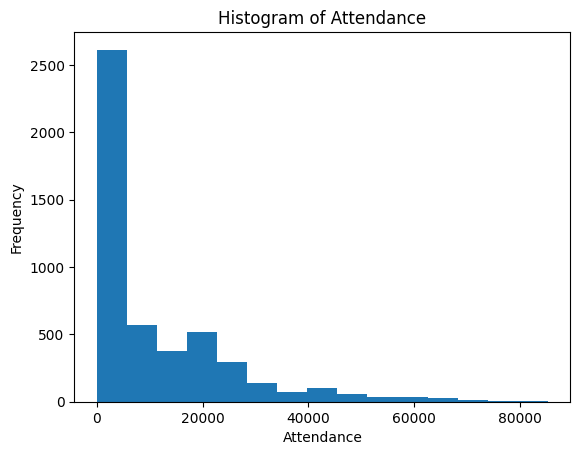

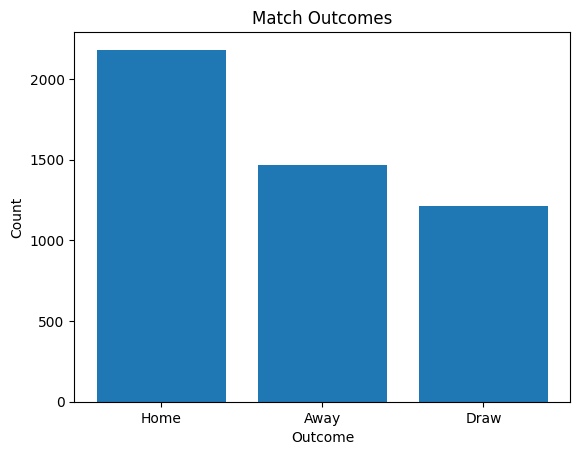

In [61]:
# Visualized attendance distribution and overall match outcomes

import matplotlib.pyplot as plt

plt.hist(teamFixtures["attendance"], bins=15)
plt.title("Histogram of Attendance")
plt.xlabel("Attendance")
plt.ylabel("Frequency")
plt.show()

plt.bar(["Home", "Away", "Draw"], [home_wins, away_wins, draws])
plt.title("Match Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

The goal difference histogram is centered near 0, with most games decided by only a few goals. It is slightly right-skewed, showing that home teams more often win by positive goal differences.

I chose a bar chart because it clearly compares the total number of home wins, away wins, and draws.

In [63]:
# Model how well attendance predicts home team wins using linear regression
from sklearn.linear_model import LinearRegression

X = teamFixtures["attendance"].values.reshape(-1, 1)
Y = teamFixtures["homeTeamWinner"].astype(int)

model = LinearRegression()
model.fit(X, Y)

print(model.score(X, Y))

0.003450589907940005


Final answer: Yes, home teams won more often than away teams in this dataset. Home teams won 2,182 games, while away teams won 1,469 games.
Interpretation: Goal difference explains 58% of the variation in whether or not a home team wins.